In [2]:
import shutil
import os

# Define source and destination paths
source_dir = '/kaggle/input/brain-tumor-mri-dataset/Training'
dest_dir = '/kaggle/working/brain-tumor-mri-dataset/Training'

# Copy the entire directory
shutil.copytree(source_dir, dest_dir)

# List the copied files to ensure they've been copied
os.listdir(dest_dir)
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import hashlib

def dhash(image, hash_size=8):
    resized = cv2.resize(image, (hash_size + 1, hash_size))
    diff = resized[:, 1:] > resized[:, :-1]
    return sum([2 ** i for (i, v) in enumerate(diff.flatten()) if v])

def remove_duplicates(data_dir):
    image_hashes = {}
    duplicates = []

    for category in os.listdir(data_dir):
        category_path = os.path.join(dest_dir, category)

        for img_name in os.listdir(category_path):
            img_path = os.path.join(category_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            img_hash = dhash(img)

            if img_hash in image_hashes:
                print(f"Duplicate found: {img_name} is a duplicate of {image_hashes[img_hash]}")
                duplicates.append(img_path)
            else:
                image_hashes[img_hash] = img_name

    for duplicate in duplicates:
        os.remove(duplicate)
        print(f"Deleted duplicate image: {duplicate}")

remove_duplicates(dest_dir)

Duplicate found: Tr-me_0249.jpg is a duplicate of Tr-me_0251.jpg
Duplicate found: Tr-me_0227.jpg is a duplicate of Tr-me_0238.jpg
Duplicate found: Tr-me_0617.jpg is a duplicate of Tr-me_0616.jpg
Duplicate found: Tr-me_0281.jpg is a duplicate of Tr-me_0175.jpg
Duplicate found: Tr-me_0176.jpg is a duplicate of Tr-me_0366.jpg
Duplicate found: Tr-me_0211.jpg is a duplicate of Tr-me_0366.jpg
Duplicate found: Tr-no_0335.jpg is a duplicate of Tr-no_0394.jpg
Duplicate found: Tr-no_0460.jpg is a duplicate of Tr-no_1303.jpg
Duplicate found: Tr-no_0741.jpg is a duplicate of Tr-no_1038.jpg
Duplicate found: Tr-no_0332.jpg is a duplicate of Tr-no_0350.jpg
Duplicate found: Tr-no_1223.jpg is a duplicate of Tr-no_0674.jpg
Duplicate found: Tr-no_0231.jpg is a duplicate of Tr-no_0012.jpg
Duplicate found: Tr-no_1131.jpg is a duplicate of Tr-no_0012.jpg
Duplicate found: Tr-no_0982.jpg is a duplicate of Tr-no_0350.jpg
Duplicate found: Tr-no_0340.jpg is a duplicate of Tr-no_1153.jpg
Duplicate found: Tr-no_02

In [7]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split

def load_and_preprocess_images(data_dir, target_size=(256, 256), category="notumor"):
    images = []
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}
    
    if not os.path.exists(data_dir):
        raise FileNotFoundError(f"The directory {data_dir} does not exist.")
    
    category_path = os.path.join(data_dir, category)
    if not os.path.exists(category_path):
        raise FileNotFoundError(f"The category directory {category_path} does not exist.")
    
    print(f"Processing category: {category}")
    for img_name in os.listdir(category_path):
        if any(img_name.lower().endswith(ext) for ext in valid_extensions):
            img_path = os.path.join(category_path, img_name)
            try:
                img = load_img(img_path, color_mode='grayscale', target_size=target_size)
                img_array = img_to_array(img)
                images.append(img_array)
            except Exception as e:
                print(f"Error loading image {img_path}: {str(e)}")
    
    if not images:
        raise ValueError(f"No valid images found in the {category} directory.")
    
    print(f"Total images loaded: {len(images)}")
    
    return np.array(images)

def normalize_images(images):
    return (images / 127.5) - 1

def create_datasets(images, batch_size=32, validation_split=0.2):
    if len(images) == 0:
        raise ValueError("The images array is empty. Please check the data loading process.")
    
    train_images, val_images = train_test_split(
        images, test_size=validation_split, random_state=42
    )
    
    train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(1000).batch(batch_size)
    val_dataset = tf.data.Dataset.from_tensor_slices(val_images).batch(batch_size)
    
    print(f"Training set size: {len(train_images)}")
    print(f"Validation set size: {len(val_images)}")
    
    return train_dataset, val_dataset

# Usage example
if __name__ == "__main__":
    data_dir = '/kaggle/working/brain-tumor-mri-dataset/Training'
    images = load_and_preprocess_images(data_dir, category="notumor")
    normalized_images = normalize_images(images)
    train_dataset, val_dataset = create_datasets(normalized_images)
    print("Datasets created successfully.")

Processing category: notumor
Total images loaded: 1307
Training set size: 1045
Validation set size: 262
Datasets created successfully.


In [13]:
class ImprovedGenerator(models.Model):
    def __init__(self, latent_dim):
        super(ImprovedGenerator, self).__init__()
        self.latent_dim = latent_dim
        
        self.model = models.Sequential([
            layers.Dense(16 * 16 * 256, use_bias=False, input_shape=(latent_dim,)),
            layers.BatchNormalization(),
            layers.LeakyReLU(alpha=0.2),
            
            layers.Reshape((16, 16, 256)),
            self._upsample_block(128),
            self._upsample_block(64),
            self._upsample_block(32),
            
            layers.Conv2DTranspose(1, (4, 4), strides=(2, 2), padding='same', use_bias=False, activation='tanh')
        ])

    def _upsample_block(self, filters):
        return models.Sequential([
            layers.Conv2DTranspose(filters, (4, 4), strides=(2, 2), padding='same', use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(alpha=0.2)
        ])

    def call(self, inputs):
        return self.model(inputs)

# Improved Discriminator
class ImprovedDiscriminator(models.Model):
    def __init__(self):
        super(ImprovedDiscriminator, self).__init__()
        
        self.model = models.Sequential([
            self._downsample_block(64, apply_batchnorm=False),
            self._downsample_block(128),
            self._downsample_block(256),
            self._downsample_block(512),
            
            layers.Flatten(),
            layers.Dense(1)
        ])

    def _downsample_block(self, filters, apply_batchnorm=True):
        block = models.Sequential([
            layers.Conv2D(filters, (4, 4), strides=(2, 2), padding='same', use_bias=False),
            layers.LeakyReLU(alpha=0.2)
        ])
        if apply_batchnorm:
            block.add(layers.BatchNormalization())
        return block

    def call(self, inputs):
        return self.model(inputs)

# Improved GAN
class ImprovedGAN(models.Model):
    def __init__(self, latent_dim, discriminator, generator):
        super(ImprovedGAN, self).__init__()
        self.latent_dim = latent_dim
        self.discriminator = discriminator
        self.generator = generator

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super(ImprovedGAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    @tf.function
    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]
        noise = tf.random.normal([batch_size, self.latent_dim])

        # Data augmentation
        real_images = tf.map_fn(augment_image, real_images)

        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
            generated_images = self.generator(noise, training=True)

            real_output = self.discriminator(real_images, training=True)
            fake_output = self.discriminator(generated_images, training=True)

            gen_loss = self.generator_loss(fake_output)
            disc_loss = self.discriminator_loss(real_output, fake_output)

        gradients_of_generator = gen_tape.gradient(gen_loss, self.generator.trainable_variables)
        gradients_of_discriminator = disc_tape.gradient(disc_loss, self.discriminator.trainable_variables)

        self.g_optimizer.apply_gradients(zip(gradients_of_generator, self.generator.trainable_variables))
        self.d_optimizer.apply_gradients(zip(gradients_of_discriminator, self.discriminator.trainable_variables))

        return {"d_loss": disc_loss, "g_loss": gen_loss}

    def generator_loss(self, fake_output):
        return self.loss_fn(tf.ones_like(fake_output), fake_output)

    def discriminator_loss(self, real_output, fake_output):
        real_loss = self.loss_fn(tf.ones_like(real_output), real_output)
        fake_loss = self.loss_fn(tf.zeros_like(fake_output), fake_output)
        total_loss = real_loss + fake_loss
        return total_loss

# Evaluation Metrics
def calculate_fid(real_features, generated_features):
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = generated_features.mean(axis=0), np.cov(generated_features, rowvar=False)
    
    ssdiff = np.sum((mu1 - mu2)**2.0)
    covmean = sqrtm(sigma1.dot(sigma2))
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

# Visualization
def generate_and_save_images(model, epoch, test_input):
    predictions = model.generator(test_input, training=False)
    
    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 0.5 + 0.5, cmap='gray')
        plt.axis('off')
    
    plt.savefig(f'generated_image_epoch_{epoch:04d}.png')
    plt.close()

# Training Loop
def train(gan, dataset, epochs):
    seed = tf.random.normal([16, gan.latent_dim])
    
    for epoch in range(epochs):

        
        for image_batch in dataset:
            gan.train_step(image_batch)
        
        # Generate and save images
        if (epoch + 1) % 10 == 0:
            generate_and_save_images(gan, epoch + 1, seed)
        
        # Print progress

        print(f'Epoch {epoch + 1}/{epochs}')
    
    # Generate a final set of images after the training is complete
    generate_and_save_images(gan, epochs, seed)

# Main execution
if __name__ == "__main__":
    # Hyperparameters
    LATENT_DIM = 100
    LEARNING_RATE = 1e-4
    BETA_1 = 0.5
    BATCH_SIZE = 64
    EPOCHS = 100
    
    # Load and preprocess data
    
    
    # Create and compile the improved GAN
    generator = ImprovedGenerator(LATENT_DIM)
    discriminator = ImprovedDiscriminator()
    
    gan = ImprovedGAN(LATENT_DIM, discriminator, generator)
    gan.compile(
        d_optimizer=optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1),
        g_optimizer=optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1),
        loss_fn=tf.keras.losses.BinaryCrossentropy(from_logits=True)
    )
    
    # Train the GAN
    train(gan, train_dataset, EPOCHS)

Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/100
Epoch 75/100
Epoch 76/100
Epoch 77/100
Epoch 78

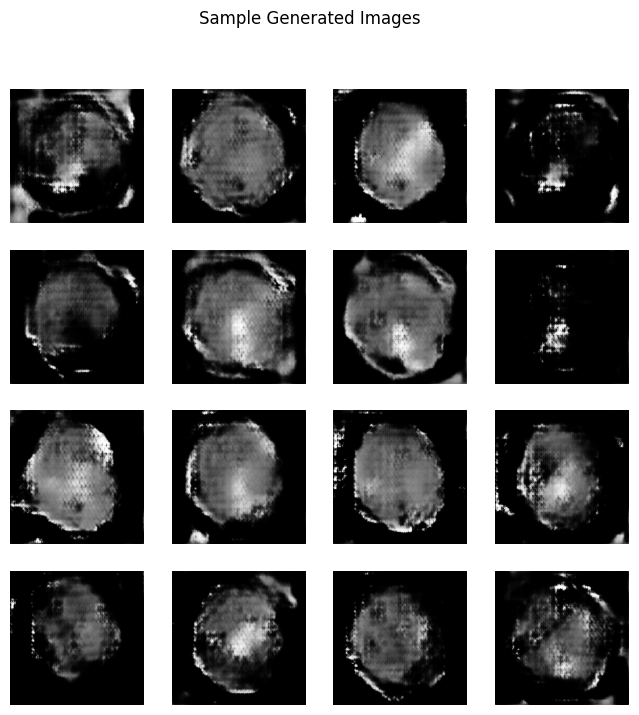

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

def generate_images(gan, latent_dim, num_images=16):
    """
    Generate images using the GAN's generator.

    Parameters:
        gan (GAN model): The trained GAN model.
        latent_dim (int): The dimensionality of the latent space.
        num_images (int): Number of images to generate.

    Returns:
        numpy array: Generated images.
    """
    # Generate random latent vectors
    latent_vectors = tf.random.normal(shape=(num_images, latent_dim))
    
    # Generate images from latent vectors
    generated_images = gan.generator(latent_vectors, training=False)
    
    # Convert the generated images to numpy arrays and scale to [0, 1]
    generated_images = (generated_images + 1) / 2.0  # Assuming images are normalized to [-1, 1]

    return generated_images.numpy()

def plot_generated_images(images, title="Generated Images"):
    """
    Plot multiple generated images in a grid.

    Parameters:
        images (numpy array): The images to display.
        title (str): Title of the plot.
    """
    num_images = images.shape[0]
    grid_size = int(np.sqrt(num_images))
    
    plt.figure(figsize=(8, 8))
    for i in range(num_images):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(images[i, :, :, 0], cmap='gray')  # Assuming grayscale images; adjust for RGB if needed
        plt.axis('off')
    
    plt.suptitle(title)
    plt.show()

# Example usage
latent_dim = 100  # The dimension of the latent space used in your GAN
num_images = 16    # Number of images to generate

# Generate images from the GAN model
generated_images = generate_images(gan, latent_dim, num_images)

# Plot the generated images
plot_generated_images(generated_images, title="Sample Generated Images")


In [15]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Data Preprocessing
def load_and_preprocess_images(data_dir, target_size=(256, 256)):
    images = []
    for img_name in os.listdir(data_dir):
        if img_name.endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(data_dir, img_name)
            img = load_img(img_path, color_mode='grayscale', target_size=target_size)
            img_array = img_to_array(img)
            images.append(img_array)
    
    return np.array(images)

def normalize_images(images):
    return (images / 127.5) - 1

def create_datasets(images, batch_size=32, validation_split=0.2):
    train_images, val_images = train_test_split(images, test_size=validation_split, random_state=42)
    
    train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(1000).batch(batch_size)
    val_dataset = tf.data.Dataset.from_tensor_slices(val_images).batch(batch_size)
    
    return train_dataset, val_dataset

def preprocess_mri_dataset(data_dir, target_size=(256, 256), batch_size=32, validation_split=0.2):
    images = load_and_preprocess_images(data_dir, target_size)
    normalized_images = normalize_images(images)
    train_dataset, val_dataset = create_datasets(normalized_images, batch_size, validation_split)
    return train_dataset, val_dataset

# DCGAN Model
def build_generator(latent_dim):
    model = models.Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(16 * 16 * 256),
        layers.Reshape((16, 16, 256)),
        layers.Conv2DTranspose(128, kernel_size=5, strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2DTranspose(32, kernel_size=5, strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2DTranspose(1, kernel_size=5, strides=2, padding='same', activation='tanh')
    ])
    return model

def build_discriminator(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(64, kernel_size=5, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(128, kernel_size=5, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(256, kernel_size=5, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(512, kernel_size=5, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.Flatten(),
        layers.Dense(1)
    ])
    return model

class DCGAN(models.Model):
    def __init__(self, latent_dim, input_shape):
        super(DCGAN, self).__init__()
        self.latent_dim = latent_dim
        self.generator = build_generator(latent_dim)
        self.discriminator = build_discriminator(input_shape)
        
    def compile(self, g_optimizer, d_optimizer, loss_fn):
        super(DCGAN, self).compile()
        self.g_optimizer = g_optimizer
        self.d_optimizer = d_optimizer
        self.loss_fn = loss_fn

    @tf.function
    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]
        latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))

        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
            generated_images = self.generator(latent_vectors, training=True)

            real_output = self.discriminator(real_images, training=True)
            fake_output = self.discriminator(generated_images, training=True)

            gen_loss = self.loss_fn(tf.ones_like(fake_output), fake_output)
            real_loss = self.loss_fn(tf.ones_like(real_output), real_output)
            fake_loss = self.loss_fn(tf.zeros_like(fake_output), fake_output)
            disc_loss = real_loss + fake_loss

        gradients_of_generator = gen_tape.gradient(gen_loss, self.generator.trainable_variables)
        gradients_of_discriminator = disc_tape.gradient(disc_loss, self.discriminator.trainable_variables)

        self.g_optimizer.apply_gradients(zip(gradients_of_generator, self.generator.trainable_variables))
        self.d_optimizer.apply_gradients(zip(gradients_of_discriminator, self.discriminator.trainable_variables))
        
        return {"d_loss": disc_loss, "g_loss": gen_loss}

# Image Generation and Saving
def generate_and_save_images(model, epoch, test_input):
    predictions = model.generator(test_input, training=False)
    
    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 0.5 + 0.5, cmap='gray')
        plt.axis('off')
    
    plt.savefig(f'dcgan_generated_image_epoch_{epoch}.png')
    plt.close()

# Training Function
def train_dcgan(dcgan, dataset, epochs, latent_dim):
    test_input = tf.random.normal([16, latent_dim])
    
    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")
        for batch in dataset:
            losses = dcgan.train_step(batch)
        
        print(f"Discriminator Loss: {losses['d_loss']:.4f}, Generator Loss: {losses['g_loss']:.4f}")
        
        if (epoch + 1) % 10 == 0:
            generate_and_save_images(dcgan, epoch + 1, test_input)

# Evaluation Functions
def inception_score(images, model, batch_size=32, splits=10):
    def _softmax(x):
        return tf.nn.softmax(x)

    def _kl_divergence(p, q):
        return tf.reduce_sum(p * tf.math.log(p / q), axis=1)
    
    preds = []
    n_batches = len(images) // batch_size
    for i in range(n_batches):
        batch = images[i * batch_size: (i + 1) * batch_size]
        batch_preds = model.predict(batch)
        preds.append(batch_preds)
    
    preds = np.concatenate(preds, axis=0)
    scores = []
    for i in range(splits):
        part = preds[(i * len(preds) // splits):((i + 1) * len(preds) // splits), :]
        kl = _kl_divergence(_softmax(np.mean(part, axis=0, keepdims=True)),
                            _softmax(part))
        scores.append(np.exp(np.mean(kl)))
    return np.mean(scores), np.std(scores)

def calculate_fid(real_features, generated_features):
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = generated_features.mean(axis=0), np.cov(generated_features, rowvar=False)
    
    ssdiff = np.sum((mu1 - mu2) ** 2.0)
    covmean = scipy.linalg.sqrtm(sigma1.dot(sigma2))
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

def evaluate_dcgan(dcgan, val_dataset, inception_model):
    real_images = np.concatenate([batch.numpy() for batch in val_dataset], axis=0)
    
    num_eval_samples = len(real_images)
    latent_vectors = tf.random.normal(shape=(num_eval_samples, dcgan.latent_dim))
    generated_images = dcgan.generator(latent_vectors, training=False)
    
    # Preprocess images for Inception model
    real_images_rgb = np.repeat(real_images, 3, axis=-1)
    generated_images_rgb = np.repeat(generated_images, 3, axis=-1)
    
    real_features = inception_model.predict(real_images_rgb)
    generated_features = inception_model.predict(generated_images_rgb)
    
    fid_score = calculate_fid(real_features, generated_features)
    is_score, is_std = inception_score(generated_images_rgb, inception_model)
    
    print(f"FID Score: {fid_score}")
    print(f"Inception Score: {is_score} ± {is_std}")

# Main Execution
if __name__ == "__main__":
    # Hyperparameters
    latent_dim = 100
    input_shape = (256, 256, 1)
    batch_size = 32
    epochs = 100
    learning_rate = 0.0002
    beta_1 = 0.5

    # Load and preprocess the dataset
    data_dir = '/kaggle/working/brain-tumor-mri-dataset/Training/notumor'
    train_dataset, val_dataset = preprocess_mri_dataset(data_dir, input_shape[:2], batch_size)

    # Create and compile the DCGAN
    dcgan = DCGAN(latent_dim, input_shape)
    dcgan.compile(
        g_optimizer=optimizers.Adam(learning_rate=learning_rate, beta_1=beta_1),
        d_optimizer=optimizers.Adam(learning_rate=learning_rate, beta_1=beta_1),
        loss_fn=tf.keras.losses.BinaryCrossentropy(from_logits=True)
    )

    # Train the DCGAN
    train_dcgan(dcgan, train_dataset, epochs, latent_dim)

    # Load pre-trained Inception model for evaluation
    inception_model = tf.keras.applications.InceptionV3(include_top=False, pooling='avg', weights='imagenet')

    # Evaluate the DCGAN
    evaluate_dcgan(dcgan, val_dataset, inception_model)

Epoch 1/100
Discriminator Loss: 0.0087, Generator Loss: 5.5496
Epoch 2/100
Discriminator Loss: 0.2869, Generator Loss: 2.6572
Epoch 3/100
Discriminator Loss: 0.2752, Generator Loss: 3.7092
Epoch 4/100
Discriminator Loss: 5.4791, Generator Loss: 0.0091
Epoch 5/100
Discriminator Loss: 0.1616, Generator Loss: 8.2821
Epoch 6/100
Discriminator Loss: 0.4993, Generator Loss: 1.8502
Epoch 7/100
Discriminator Loss: 0.8149, Generator Loss: 1.3357
Epoch 8/100
Discriminator Loss: 0.6747, Generator Loss: 2.0932
Epoch 9/100
Discriminator Loss: 1.5169, Generator Loss: 4.5687
Epoch 10/100
Discriminator Loss: 0.5142, Generator Loss: 2.9302
Epoch 11/100
Discriminator Loss: 0.9856, Generator Loss: 2.8327
Epoch 12/100
Discriminator Loss: 0.4222, Generator Loss: 2.2287
Epoch 13/100
Discriminator Loss: 0.1974, Generator Loss: 3.1882
Epoch 14/100
Discriminator Loss: 0.4416, Generator Loss: 1.6483
Epoch 15/100
Discriminator Loss: 0.6184, Generator Loss: 1.3251
Epoch 16/100
Discriminator Loss: 0.2929, Generato

I0000 00:00:1726149140.862140     162 service.cc:145] XLA service 0x7d0932ea4780 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1726149140.862203     162 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


5/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

I0000 00:00:1726149146.954669     162 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 875ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


NameError: name 'scipy' is not defined

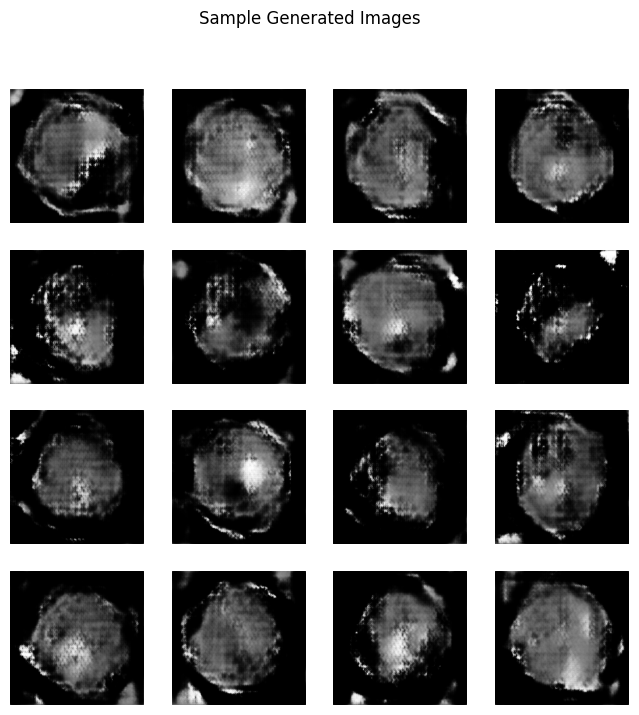

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

def generate_images(gan, latent_dim, num_images=16):
    """
    Generate images using the GAN's generator.

    Parameters:
        gan (GAN model): The trained GAN model.
        latent_dim (int): The dimensionality of the latent space.
        num_images (int): Number of images to generate.

    Returns:
        numpy array: Generated images.
    """
    # Generate random latent vectors
    latent_vectors = tf.random.normal(shape=(num_images, latent_dim))
    
    # Generate images from latent vectors
    generated_images = gan.generator(latent_vectors, training=False)
    
    # Convert the generated images to numpy arrays and scale to [0, 1]
    generated_images = (generated_images + 1) / 2.0  # Assuming images are normalized to [-1, 1]

    return generated_images.numpy()

def plot_generated_images(images, title="Generated Images"):
    """
    Plot multiple generated images in a grid.

    Parameters:
        images (numpy array): The images to display.
        title (str): Title of the plot.
    """
    num_images = images.shape[0]
    grid_size = int(np.sqrt(num_images))
    
    plt.figure(figsize=(8, 8))
    for i in range(num_images):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(images[i, :, :, 0], cmap='gray')  # Assuming grayscale images; adjust for RGB if needed
        plt.axis('off')
    
    plt.suptitle(title)
    plt.show()

# Example usage
latent_dim = 100  # The dimension of the latent space used in your GAN
num_images = 16    # Number of images to generate

# Generate images from the GAN model
generated_images = generate_images(gan, latent_dim, num_images)

# Plot the generated images
plot_generated_images(generated_images, title="Sample Generated Images")
